In [75]:
# Necessary imports
import importlib
import analysis_functions as af
importlib.reload(af)
run_name = "1_Iteration_One_v2" # Replace with correct run name
n = af.get_network(run_name)
scenario = 'no_cfd'   # Replace with correct scenario name if needed ('cap','no_cfd')
nyears = len(n.snapshots) / 8760

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


In [12]:
importlib.reload(af)
af.plot_price_duration_curve(run_name)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/price_duration_curve.png


In [23]:
prices_t = af.get_hourly_marginal_price(n)
max_price = prices_t.max()
print(f'Maximum marginal price: {max_price} €/MWh')
stats = af.price_statistics(n)
print(f"Price statistics: {stats}")

Maximum marginal price: 3999.999982501348 €/MWh
Price statistics: {'mean': 61.44879050769329, 'median': 64.29153547592509, 'std_dev': 155.77773113487103, 'min': 0.018700825950200985, 'max': 3999.999982501348}


In [10]:
importlib.reload(af)
af.plot_avg_annual_generation(run_name)
af.plot_installed_capacities(run_name)

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/average_annual_generation_all_carriers.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/installed_capacities_all_carriers.png


In [2]:
offshore_ac_cap = n.generators.p_nom_opt[n.generators.carrier == 'offwind-ac'].sum()
print(f"Total installed offshore AC capacity: {offshore_ac_cap} MW")
offshore_dc_cap = n.generators.p_nom_opt[n.generators.carrier == 'offwind-dc'].sum()
print(f"Total installed offshore DC capacity: {offshore_dc_cap} MW")
offshore_float_cap = n.generators.p_nom_opt[n.generators.carrier == 'offwind-float'].sum()
print(f"Total installed offshore floating capacity: {offshore_float_cap} MW")
onshore_wind_cap = n.generators.p_nom_opt[n.generators.carrier == 'onwind'].sum()
print(f"Total installed onshore wind capacity: {onshore_wind_cap} MW")
solar_cap = n.generators.p_nom_opt[n.generators.carrier == 'solar'].sum()
print(f"Total installed solar capacity: {solar_cap} MW")
solar_hsat_cap = n.generators.p_nom_opt[n.generators.carrier == 'solar-hsat'].sum()
print(f"Total installed solar HSAT capacity: {solar_hsat_cap} MW")
hydro_cap = n.generators.p_nom_opt[n.generators.carrier == 'ror'].sum()
print(f"Total installed hydro generation capacity: {hydro_cap} MW")
bio_cap = n.generators.p_nom_opt[n.generators.carrier == 'biomass'].sum()
print(f"Total installed bioenergy capacity: {bio_cap} MW")
geothermal_cap = n.generators.p_nom_opt[n.generators.carrier == 'geothermal'].sum()
print(f"Total installed geothermal capacity: {geothermal_cap} MW")
ccgt_cap = n.generators.p_nom_opt[n.generators.carrier == 'CCGT'].sum()
print(f"Total installed CCGT capacity: {ccgt_cap} MW")
ocgt_cap = n.generators.p_nom_opt[n.generators.carrier == 'OCGT'].sum()
print(f"Total installed OCGT capacity: {ocgt_cap} MW")
battery_cap = n.storage_units.p_nom_opt[n.storage_units.carrier == 'battery'].sum()
print(f"Total installed battery capacity: {battery_cap} MW")
hydrogen_cap = n.storage_units.p_nom_opt[n.storage_units.carrier == 'hydrogen'].sum()
print(f"Total installed hydrogen capacity: {hydrogen_cap} MW")
load_cap = n.generators.p_nom_opt[n.generators.carrier == 'load'].sum()
print(f"Total load shedding capacity: {load_cap} MW")

Total installed offshore AC capacity: 3041.013424156643 MW
Total installed offshore DC capacity: 41368.4601148902 MW
Total installed offshore floating capacity: 0.43438308886439364 MW
Total installed onshore wind capacity: 45553.42687150418 MW
Total installed solar capacity: 178.90822795590037 MW
Total installed solar HSAT capacity: 163029.40351737544 MW
Total installed hydro generation capacity: 3617.2588089999995 MW
Total installed bioenergy capacity: 7730.271833000001 MW
Total installed geothermal capacity: 23.9 MW
Total installed CCGT capacity: 22415.159613986812 MW
Total installed OCGT capacity: 53495.99659805744 MW
Total installed battery capacity: 17522.200343311262 MW
Total installed hydrogen capacity: 0.0 MW
Total load shedding capacity: 36542.13572564269 MW


In [10]:
offshore_ac_gen = n.generators_t.p.loc[:, n.generators.carrier == 'offwind-ac'].sum().sum()
print(f"Total offshore AC generation: {offshore_ac_gen} MWh")
offshore_dc_gen = n.generators_t.p.loc[:, n.generators.carrier == 'offwind-dc'].sum().sum()
print(f"Total offshore DC generation: {offshore_dc_gen} MWh")
offshore_float_gen = n.generators_t.p.loc[:, n.generators.carrier == 'offwind-float'].sum().sum()
print(f"Total offshore floating generation: {offshore_float_gen} MWh")
onshore_wind_gen = n.generators_t.p.loc[:, n.generators.carrier == 'onwind'].sum().sum()
print(f"Total onshore wind generation: {onshore_wind_gen} MWh")
solar_gen = n.generators_t.p.loc[:, n.generators.carrier == 'solar'].sum().sum()
print(f"Total solar generation: {solar_gen} MWh")
solar_hsat_gen = n.generators_t.p.loc[:, n.generators.carrier == 'solar-hsat'].sum().sum()
print(f"Total solar HSAT generation: {solar_hsat_gen} MWh")
ccgt_gen = n.generators_t.p.loc[:, n.generators.carrier == 'CCGT'].sum().sum()
print(f"Total CCGT generation: {ccgt_gen} MWh")
ocgt_gen = n.generators_t.p.loc[:, n.generators.carrier == 'OCGT'].sum().sum()
print(f"Total OCGT generation: {ocgt_gen} MWh")
battery_gen = n.storage_units_t.p.loc[:, n.storage_units.carrier == 'battery'].sum().sum()
print(f"Total battery discharge: {battery_gen} MWh")
hydrogen_gen = n.storage_units_t.p.loc[:, n.storage_units.carrier == 'hydrogen'].sum().sum()
print(f"Total hydrogen discharge: {hydrogen_gen} MWh")
load_gen = n.generators_t.p.loc[:, n.generators.carrier == 'load'].sum().sum()
print(f"Total load shedding: {load_gen} MWh")

Total offshore AC generation: 463839661.56819725 MWh
Total offshore DC generation: 6388194015.939276 MWh
Total offshore floating generation: 47720.941630361 MWh
Total onshore wind generation: 4077187085.8447285 MWh
Total solar generation: 5302332.2496358305 MWh
Total solar HSAT generation: 7197075488.259207 MWh
Total CCGT generation: 2446124655.0794163 MWh
Total OCGT generation: 1220971079.038218 MWh
Total battery discharge: -41120198.92480653 MWh
Total hydrogen discharge: 0.0 MWh
Total load shedding: 1840466.628020262 MWh


In [22]:
importlib.reload(af)

# Print average market value per carrier
for carrier in ['onwind', 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat', 'ror', 'biomass', 'geothermal', 'CCGT', 'OCGT']:
    avg_mv = af.average_market_value_for_carrier(n, carrier)
    print(f"Average market value for {carrier}: {avg_mv:.2f} €/MWh")
    print('____________________________________________________________')

# Aggregate wind market value (scalar)
price_t = af.get_hourly_marginal_price(n, bus="DE0 0")
wind_mask = n.generators.carrier.isin(['onwind', 'offwind-ac', 'offwind-dc', 'offwind-float'])
wind_gen_t = n.generators_t.p.loc[:, wind_mask]
total_rev_wind = wind_gen_t.mul(price_t, axis=0).sum().sum()
total_gen_wind = wind_gen_t.sum().sum()
total_avg_mv_wind = total_rev_wind / total_gen_wind if total_gen_wind != 0 else 0.0
print(f"Total average market value for all wind: {total_avg_mv_wind:.2f} €/MWh")
print('____________________________________________________________')

# Aggregate solar market value (scalar)
solar_mask = n.generators.carrier.isin(['solar', 'solar-hsat'])
solar_gen_t = n.generators_t.p.loc[:, solar_mask]
total_rev_solar = solar_gen_t.mul(price_t, axis=0).sum().sum()
total_gen_solar = solar_gen_t.sum().sum()
total_avg_mv_solar = total_rev_solar / total_gen_solar if total_gen_solar != 0 else 0.0
print(f"Total average market value for all solar: {total_avg_mv_solar:.2f} €/MWh")

Average market value for onwind: 43.50 €/MWh
____________________________________________________________
Average market value for offwind-ac: 51.93 €/MWh
____________________________________________________________
Average market value for offwind-dc: 50.77 €/MWh
____________________________________________________________
Average market value for offwind-float: 53.40 €/MWh
____________________________________________________________
Average market value for solar: 37.55 €/MWh
____________________________________________________________
Average market value for solar-hsat: 30.66 €/MWh
____________________________________________________________
Average market value for ror: 64.85 €/MWh
____________________________________________________________
Average market value for biomass: 104.33 €/MWh
____________________________________________________________
Average market value for geothermal: 96.92 €/MWh
____________________________________________________________
Average market value for 

In [3]:
importlib.reload(af)
for carrier in ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat']:
    af.plot_resource_classes_capacities(run_name, carrier)

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Plot saved to ../results/1_Iteration_One_v2/my_plots/capacities_onwind.png


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/capacities_offwind-ac.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One_v2/my_plots/capacities_offwind-float.png


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/capacities_solar.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


Plot saved to ../results/1_Iteration_One_v2/my_plots/capacities_solar-hsat.png


In [11]:
carriers = ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat']
for carrier in carriers:
    print(n.generators.p_nom_max[n.generators.carrier == carrier])

Generator
DE0 0 0 onwind    45743.748412
DE0 0 1 onwind    54117.371817
DE0 0 2 onwind    58251.682710
DE0 0 3 onwind    52098.507213
DE0 0 4 onwind    50581.054172
DE0 0 5 onwind    48267.020574
DE0 0 6 onwind    49078.275810
DE0 0 7 onwind    53092.707911
DE0 0 8 onwind    48638.074786
DE0 0 9 onwind    27968.461352
Name: p_nom_max, dtype: float64
Generator
DE0 0 0 offwind-ac    1665.263405
DE0 0 1 offwind-ac    9208.864488
DE0 0 2 offwind-ac    2709.720028
DE0 0 3 offwind-ac       0.000000
Name: p_nom_max, dtype: float64
Generator
DE0 0 0 offwind-dc        0.000000
DE0 0 1 offwind-dc        3.802769
DE0 0 2 offwind-dc    13833.554458
DE0 0 3 offwind-dc    50358.495144
Name: p_nom_max, dtype: float64
Generator
DE0 0 0 offwind-float    144.467403
DE0 0 1 offwind-float    182.920728
DE0 0 2 offwind-float    108.231258
DE0 0 3 offwind-float     74.667750
Name: p_nom_max, dtype: float64
Generator
DE0 0 0 solar    130636.363632
DE0 0 1 solar    135780.573709
DE0 0 2 solar    107387.176322

In [12]:
carriers = ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat', 'CCGT']
for carrier in carriers:
    print(n.generators.capital_cost[n.generators.carrier == carrier]*35/nyears)


Generator
DE0 0 0 onwind    3.127969e+06
DE0 0 1 onwind    3.119084e+06
DE0 0 2 onwind    3.118160e+06
DE0 0 3 onwind    3.115482e+06
DE0 0 4 onwind    3.114390e+06
DE0 0 5 onwind    3.116298e+06
DE0 0 6 onwind    3.116572e+06
DE0 0 7 onwind    3.116883e+06
DE0 0 8 onwind    3.120206e+06
DE0 0 9 onwind    3.127324e+06
Name: capital_cost, dtype: float64
Generator
DE0 0 0 offwind-ac    6.651806e+06
DE0 0 1 offwind-ac    6.693376e+06
DE0 0 2 offwind-ac    6.958907e+06
DE0 0 3 offwind-ac    7.010655e+06
Name: capital_cost, dtype: float64
Generator
DE0 0 0 offwind-dc    7.499943e+06
DE0 0 1 offwind-dc    7.432106e+06
DE0 0 2 offwind-dc    7.470627e+06
DE0 0 3 offwind-dc    8.152775e+06
Name: capital_cost, dtype: float64
Generator
DE0 0 0 offwind-float    9.760443e+06
DE0 0 1 offwind-float    9.790234e+06
DE0 0 2 offwind-float    1.012679e+07
DE0 0 3 offwind-float    1.111375e+07
Name: capital_cost, dtype: float64
Generator
DE0 0 0 solar    1.121176e+06
DE0 0 1 solar    1.120683e+06
DE0 0 2 

In [14]:
carriers = ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat']
for carrier in carriers:
    print(n.generators.p_nom_opt[n.generators.carrier == carrier])

Generator
DE0 0 0 onwind        1.411752
DE0 0 1 onwind        0.834318
DE0 0 2 onwind        1.329380
DE0 0 3 onwind        2.208141
DE0 0 4 onwind        2.963982
DE0 0 5 onwind        3.132269
DE0 0 6 onwind       10.094200
DE0 0 7 onwind     7408.219296
DE0 0 8 onwind    21592.126729
DE0 0 9 onwind    16502.554519
Name: p_nom_opt, dtype: float64
Generator
DE0 0 0 offwind-ac       0.809597
DE0 0 1 offwind-ac     428.539725
DE0 0 2 offwind-ac    2709.685873
DE0 0 3 offwind-ac       0.000000
Name: p_nom_opt, dtype: float64
Generator
DE0 0 0 offwind-dc        0.000000
DE0 0 1 offwind-dc        3.799596
DE0 0 2 offwind-dc    13833.535550
DE0 0 3 offwind-dc    27501.332956
Name: p_nom_opt, dtype: float64
Generator
DE0 0 0 offwind-float    0.100289
DE0 0 1 offwind-float    0.127001
DE0 0 2 offwind-float    0.172661
DE0 0 3 offwind-float    0.132324
Name: p_nom_opt, dtype: float64
Generator
DE0 0 0 solar    11.088660
DE0 0 1 solar    13.581572
DE0 0 2 solar    14.565895
DE0 0 3 solar    15

In [50]:
importlib.reload(af)
af.plot_resource_classes_map(run_name, carrier='solar', save_to_file=True)
af.plot_resource_classes_map(run_name, carrier='solar-hsat', save_to_file=True)
af.plot_resource_classes_map(run_name, carrier='onwind', save_to_file=True)
af.plot_resource_classes_map(run_name, carrier='offwind-ac', save_to_file=True)
af.plot_resource_classes_map(run_name, carrier='offwind-dc', save_to_file=True)
af.plot_resource_classes_map(run_name, carrier='offwind-float', save_to_file=True)

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/map_regions_by_class_1_solar.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/map_regions_by_class_1_solar-hsat.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One_v2/my_plots/map_regions_by_class_1_offwind-ac.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/map_regions_by_class_1_offwind-dc.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/map_regions_by_class_1_offwind-float.png


In [73]:
carriers = ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat']
for carrier in carriers:
    cap_inst = n.generators.p_nom_opt[n.generators.carrier == carrier]
    cap_pot = n.generators.p_nom_max[n.generators.carrier == carrier]
    print(f"Utilization of expansion potential for {carrier}:")
    print(cap_inst / cap_pot)

Utilization of expansion potential for onwind:
Generator
DE0 0 0 onwind    0.000026
DE0 0 1 onwind    0.000016
DE0 0 2 onwind    0.000022
DE0 0 3 onwind    0.000037
DE0 0 4 onwind    0.000050
DE0 0 5 onwind    0.000059
DE0 0 6 onwind    0.000196
DE0 0 7 onwind    0.140103
DE0 0 8 onwind    0.443935
DE0 0 9 onwind    0.590042
dtype: float64
Utilization of expansion potential for offwind-ac:
Generator
DE0 0 0 offwind-ac    0.000259
DE0 0 1 offwind-ac    0.035929
DE0 0 2 offwind-ac    0.999999
DE0 0 3 offwind-ac         NaN
dtype: float64
Utilization of expansion potential for offwind-dc:
Generator
DE0 0 0 offwind-dc         NaN
DE0 0 1 offwind-dc    0.999990
DE0 0 2 offwind-dc    1.000000
DE0 0 3 offwind-dc    0.546702
dtype: float64
Utilization of expansion potential for offwind-float:
Generator
DE0 0 0 offwind-float    0.000696
DE0 0 1 offwind-float    0.000547
DE0 0 2 offwind-float    0.000948
DE0 0 3 offwind-float    0.001755
dtype: float64
Utilization of expansion potential for sola

In [16]:
carriers = ['onwind' , 'offwind-ac', 'offwind-dc', 'offwind-float', 'solar', 'solar-hsat']
for carrier in carriers:
    cap_inst = n.generators.p_nom_opt[n.generators.carrier == carrier]
    generation = n.generators_t.p.loc[:, n.generators.carrier == carrier].sum()
    print(f"Average capacity factor for {carrier}:")
    print(generation / cap_inst / len(n.snapshots))

Average capacity factor for onwind:
Generator
DE0 0 0 onwind    0.059268
DE0 0 1 onwind    0.121543
DE0 0 2 onwind    0.143906
DE0 0 3 onwind    0.168419
DE0 0 4 onwind    0.192372
DE0 0 5 onwind    0.205539
DE0 0 6 onwind    0.224651
DE0 0 7 onwind    0.235392
DE0 0 8 onwind    0.266373
DE0 0 9 onwind    0.351367
dtype: float64
Average capacity factor for offwind-ac:
Generator
DE0 0 0 offwind-ac    0.347498
DE0 0 1 offwind-ac    0.442401
DE0 0 2 offwind-ac    0.488242
DE0 0 3 offwind-ac         NaN
dtype: float64
Average capacity factor for offwind-dc:
Generator
DE0 0 0 offwind-dc         NaN
DE0 0 1 offwind-dc    0.411175
DE0 0 2 offwind-dc    0.504784
DE0 0 3 offwind-dc    0.503652
dtype: float64
Average capacity factor for offwind-float:
Generator
DE0 0 0 offwind-float    0.177456
DE0 0 1 offwind-float    0.261482
DE0 0 2 offwind-float    0.326012
DE0 0 3 offwind-float    0.365396
dtype: float64
Average capacity factor for solar:
Generator
DE0 0 0 solar    0.098827
DE0 0 1 solar   

In [17]:
print(n.storage_units.p_nom_opt)

StorageUnit
DE0 0 PHS         7828.920000
DE0 0 hydro        330.195150
DE0 0 battery    17506.316291
DE0 0 H2             0.314826
Name: p_nom_opt, dtype: float64


In [18]:
output_bat = n.storage_units_t.p.loc[:, n.storage_units.carrier == 'battery'].clip(lower=0).sum().sum()
print(f'Total battery output: {output_bat} MWh')
output_phs = n.storage_units_t.p.loc[:, n.storage_units.carrier == 'PHS'].clip(lower=0).sum().sum()
print(f'Total PHS output: {output_phs} MWh')
output_h2 = n.storage_units_t.p.loc[:, n.storage_units.carrier == 'H2'].clip(lower=0).sum().sum()
print(f'Total H2 output: {output_h2} MWh')

Total battery output: 936794882.7398388 MWh
Total PHS output: 425473739.0114251 MWh
Total H2 output: 5165.893751287589 MWh


In [102]:
importlib.reload(af)

costs = af.get_costs(run_name)
for t in [20, 30, 40]:
    # af.years_mcs(run_name, n, T=t, N=10000)
    af.revenue_mcs(costs, run_name, n, T=t, N=10000, scenarios=['pc'])


In [103]:
importlib.reload(af)

for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    for rc in range(n.generators.index[n.generators.carrier == carrier].size):
        for scenario in ['mb', 'pc', 'pb', 'pi', 'cb']:    
            avg_rev = af.avg_lifetime_revenues_mcs_per_MW(run_name, n, carrier, rc, scenario=scenario)
            print(f"Avg lifetime rev. per MW of {carrier}, rc {rc}, sc. {scenario}: {avg_rev}")
        print('-----------------------------------')

Avg lifetime rev. per MW of offwind-ac, rc 0, sc. mb: 4401212.405106108
Avg lifetime rev. per MW of offwind-ac, rc 0, sc. pc: 4219578.659885555
Avg lifetime rev. per MW of offwind-ac, rc 0, sc. pb: 4403907.842092464
Avg lifetime rev. per MW of offwind-ac, rc 0, sc. pi: 4405047.732497451
Avg lifetime rev. per MW of offwind-ac, rc 0, sc. cb: 4405463.225914886
-----------------------------------
Avg lifetime rev. per MW of offwind-ac, rc 1, sc. mb: 5737420.813779981
Avg lifetime rev. per MW of offwind-ac, rc 1, sc. pc: 5487695.669610968
Avg lifetime rev. per MW of offwind-ac, rc 1, sc. pb: 5740596.284089888
Avg lifetime rev. per MW of offwind-ac, rc 1, sc. pi: 5741256.141171326
Avg lifetime rev. per MW of offwind-ac, rc 1, sc. cb: 5741671.634588762
-----------------------------------
Avg lifetime rev. per MW of offwind-ac, rc 2, sc. mb: 6717699.454374674
Avg lifetime rev. per MW of offwind-ac, rc 2, sc. pc: 6427745.264101173
Avg lifetime rev. per MW of offwind-ac, rc 2, sc. pb: 6721615.56

In [104]:
importlib.reload(af)

for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    for rc in range(n.generators.index[n.generators.carrier == carrier].size):
        for scenario in ['mb', 'pc', 'pb', 'pi', 'cb']:    
            risk = af.risk_lifetime_revenues_mcs_per_MW(run_name, n, carrier, rc, scenario=scenario)
            print(f"Rel. rev. risk per MW of {carrier}, rc {rc}, sc. {scenario}: {risk}")
        print('-----------------------------------')

Rel. rev. risk per MW of offwind-ac, rc 0, sc. mb: 0.08260905423483038
Rel. rev. risk per MW of offwind-ac, rc 0, sc. pc: 0.06282519385315653
Rel. rev. risk per MW of offwind-ac, rc 0, sc. pb: 0.009502941172035042
Rel. rev. risk per MW of offwind-ac, rc 0, sc. pi: 0.03966430935964379
Rel. rev. risk per MW of offwind-ac, rc 0, sc. cb: 0.03722000246974384
-----------------------------------
Rel. rev. risk per MW of offwind-ac, rc 1, sc. mb: 0.08012288672109436
Rel. rev. risk per MW of offwind-ac, rc 1, sc. pc: 0.05911793570446826
Rel. rev. risk per MW of offwind-ac, rc 1, sc. pb: 0.007970792855403612
Rel. rev. risk per MW of offwind-ac, rc 1, sc. pi: 0.015108088177188356
Rel. rev. risk per MW of offwind-ac, rc 1, sc. cb: 0.0121493624945163
-----------------------------------
Rel. rev. risk per MW of offwind-ac, rc 2, sc. mb: 0.07934045673640805
Rel. rev. risk per MW of offwind-ac, rc 2, sc. pc: 0.05884930737318033
Rel. rev. risk per MW of offwind-ac, rc 2, sc. pb: 0.006569339474651277
Re

In [8]:
importlib.reload(af)

for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    for rc in range(n.generators.index[n.generators.carrier == carrier].size):
        af.revenue_statistics_comparison(run_name, carrier, n, rc)
        print('-----------------------------------')

Revenue Statistics for Offshore Wind (AC), Resource Class 0:
Statistic  Market (€)         PB CfD (€)         PI CfD (€)         CB CfD (€)        
mean       4401212.4051       4403907.8421       4405047.7325       4405463.2259      
median     4376689.8273       4404666.2383       4413137.6539       4416549.1291      
std_dev    363579.9943        41850.0772         174723.1760        163971.3521       
risk       0.0826             0.0095             0.0397             0.0372            
min        3351128.6472       4207674.8864       3667627.7022       3641498.6405      
max        6116372.1332       4540913.2331       4922139.3431       4898734.6182      
wacc       0.0606             0.0578             0.0590             0.0589            
-----------------------------------
Revenue Statistics for Offshore Wind (AC), Resource Class 1:
Statistic  Market (€)         PB CfD (€)         PI CfD (€)         CB CfD (€)        
mean       5737420.8138       5740596.2841       5741256.14

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Revenue Statistics for Offshore Wind (AC), Resource Class 3:
Statistic  Market (€)         PB CfD (€)         PI CfD (€)         CB CfD (€)        
mean       nan                nan                nan                nan               
median     nan                nan                nan                nan               
std_dev    nan                nan                nan                nan               
risk       nan                nan                nan                nan               
min        nan                nan                nan                nan               
max        nan                nan                nan                nan               
wacc       0.0700             0.0700             0.0700             0.0700            
-----------------------------------


c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1364: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Revenue Statistics for Offshore Wind (DC), Resource Class 0:
Statistic  Market (€)         PB CfD (€)         PI CfD (€)         CB CfD (€)        
mean       nan                nan                nan                nan               
median     nan                nan                nan                nan               
std_dev    nan                nan                nan                nan               
risk       nan                nan                nan                nan               
min        nan                nan                nan                nan               
max        nan                nan                nan                nan               
wacc       0.0700             0.0700             0.0700             0.0700            
-----------------------------------
Revenue Statistics for Offshore Wind (DC), Resource Class 1:
Statistic  Market (€)         PB CfD (€)         PI CfD (€)         CB CfD (€)        
mean       6741948.7284       6744799.3379       6746450.28

In [105]:
importlib.reload(af)

for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    for rc in range(n.generators.index[n.generators.carrier == carrier].size):
        for scenario in ['mb', 'pc', 'pb', 'pi', 'cb']:    
            wacc = af.wacc_updated(run_name, n, carrier, rc, scenario=scenario)
            print(f"Updated WACC for {carrier}, rc {rc}, scenario {scenario}: {wacc}")
        print('-----------------------------------')

Updated WACC for offwind-ac, rc 0, scenario mb: 0.060612263480407096
Updated WACC for offwind-ac, rc 0, scenario pc: 0.06622475759501611
Updated WACC for offwind-ac, rc 0, scenario pb: 0.05784979204147479
Updated WACC for offwind-ac, rc 0, scenario pi: 0.058974016925235614
Updated WACC for offwind-ac, rc 0, scenario cb: 0.0588821074937949
-----------------------------------
Updated WACC for offwind-ac, rc 1, scenario mb: 0.060516198212367645
Updated WACC for offwind-ac, rc 1, scenario pc: 0.06647486632051536
Updated WACC for offwind-ac, rc 1, scenario pb: 0.057793253435309055
Updated WACC for offwind-ac, rc 1, scenario pi: 0.058057097474690934
Updated WACC for offwind-ac, rc 1, scenario cb: 0.057947578006263455
-----------------------------------
Updated WACC for offwind-ac, rc 2, scenario mb: 0.06048599660561966
Updated WACC for offwind-ac, rc 2, scenario pc: 0.0665923932231409
Updated WACC for offwind-ac, rc 2, scenario pb: 0.057741585562984664
Updated WACC for offwind-ac, rc 2, scen

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1347: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Updated WACC for offwind-ac, rc 3, scenario mb: 0.07


c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1347: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.

c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1319: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Updated WACC for offwind-ac, rc 3, scenario pc: 0.029209199130192015


...

Updated WACC for offwind-dc, rc 0, scenario pb: 0.07


c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1347: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Updated WACC for offwind-dc, rc 0, scenario pi: 0.07


c:\Users\justu\Documents\PhD\RE Financing\Code\CfDs_cost_of_capital\analysis\analysis_functions.py:1347: RuntimeWarning:

The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.



Updated WACC for offwind-dc, rc 0, scenario cb: 0.07
-----------------------------------
Updated WACC for offwind-dc, rc 1, scenario mb: 0.060500866561455535
Updated WACC for offwind-dc, rc 1, scenario pc: 0.06799779989495612
Updated WACC for offwind-dc, rc 1, scenario pb: 0.05777023108297139
Updated WACC for offwind-dc, rc 1, scenario pi: 0.0580188841013144
Updated WACC for offwind-dc, rc 1, scenario cb: 0.05803208830604986
-----------------------------------
Updated WACC for offwind-dc, rc 2, scenario mb: 0.06042696348289029
Updated WACC for offwind-dc, rc 2, scenario pc: 0.06610029797430018
Updated WACC for offwind-dc, rc 2, scenario pb: 0.05777949807633893
Updated WACC for offwind-dc, rc 2, scenario pi: 0.057823340773957774
Updated WACC for offwind-dc, rc 2, scenario cb: 0.05762891815655913
-----------------------------------
Updated WACC for offwind-dc, rc 3, scenario mb: 0.060453253527030675
Updated WACC for offwind-dc, rc 3, scenario pc: 0.06650506497491457
Updated WACC for offw

In [5]:
importlib.reload(af)

af.lifetime_revenue_mcs_dist_plot(run_name, scenario='mb', carrier='offwind-dc', N=10000)
af.lifetime_revenue_mcs_dist_plot(run_name, scenario='mb', carrier='onwind', N=10000)
af.lifetime_revenue_mcs_dist_plot(run_name, scenario='mb', carrier='solar-hsat', N=10000)
af.lifetime_revenue_mcs_dist_plot(run_name, scenario='mb', carrier='solar', N=10000)

# scenarios = ['mb', 'pc', 'pb', 'pi', 'cb']
# carrier = 'onwind'
# for scenario in scenarios:
#     af.lifetime_revenue_mcs_dist_plot(run_name, scenario=scenario, carrier=carrier, N=10000)

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/norm_revenue_dist_MCS_offwind-dc_mb.png
--- Goodness of Fit Results for Offshore Wind (DC) ---
Log-Normal:  KS Stat = 0.0072, p-value = 8.9269e-02
-> The Log-Normal distribution fits the data best (lowest KS statistic).



INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/norm_revenue_dist_MCS_onwind_mb.png
--- Goodness of Fit Results for Onshore Wind ---
Log-Normal:  KS Stat = 0.0046, p-value = 3.0010e-02
-> The Log-Normal distribution fits the data best (lowest KS statistic).



INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/norm_revenue_dist_MCS_solar-hsat_mb.png
--- Goodness of Fit Results for Rotating Solar PV ---
Log-Normal:  KS Stat = 0.0055, p-value = 5.2135e-03
-> The Log-Normal distribution fits the data best (lowest KS statistic).



INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/norm_revenue_dist_MCS_solar_mb.png
--- Goodness of Fit Results for Ground-Mounted Solar PV ---
Log-Normal:  KS Stat = 0.0055, p-value = 4.2663e-03
-> The Log-Normal distribution fits the data best (lowest KS statistic).



,0,1,2,3,4,5,6,7,8,9,...,9990,9991,9992,9993,9994,9995,9996,9997,9998,9999
0,0.980556,0.980043,0.974733,1.022957,0.985081,1.070542,1.041072,0.837240,1.027503,1.031591,...,1.037356,0.909122,0.935763,0.982014,1.089814,1.072605,0.955909,0.960432,1.026965,1.099978
1,0.980476,0.989020,0.972847,1.022836,0.986102,1.071820,1.040512,0.838829,1.024347,1.035165,...,1.033935,0.907738,0.939993,0.991552,1.082256,1.072489,0.954963,0.960482,1.025859,1.093174
2,0.980734,0.989488,0.972532,1.020431,0.986022,1.067663,1.044161,0.840500,1.020729,1.035576,...,1.032093,0.907285,0.936369,0.989760,1.082565,1.070063,0.958131,0.958082,1.025540,1.093716
3,0.981837,0.994771,0.969928,1.021470,0.987737,1.067670,1.045827,0.842653,1.020817,1.039511,...,1.032294,0.908900,0.939361,0.992831,1.078081,1.071600,0.956884,0.958913,1.024796,1.091017
4,0.983528,1.000361,0.966568,1.023195,0.992071,1.070214,1.048744,0.846862,1.025177,1.041051,...,1.036243,0.914427,0.941587,0.996049,1.074602,1.074820,0.955646,0.958455,1.024756,1.091878
5,0.984353,0.998611,0.965445,1.023574,0.993265,1.066974,1.051197,0.848585,1.026232,1.041662,...,1.038671,0.917468,0.938266,0.986637,1.075681,1.076881,0.957355,0.955420,1.026589,1.096109
6,0.989515,1.006058,0.960149,1.030621,0.994373,1.069677,1.048752,0.850879,1.030160,1.045824,...,1.044040,0.918347,0.947831,0.988084,1.074131,1.084907,0.952591,0.960065,1.027104,1.094520
7,0.995933,1.017688,0.952230,1.040745,0.999480,1.075262,1.041544,0.859392,1.038356,1.049627,...,1.047171,0.921821,0.964202,0.990291,1.071432,1.093833,0.946686,0.964372,1.027737,1.088755
8,0.998789,1.013377,0.946722,1.031775,1.002441,1.063989,1.048692,0.861403,1.034449,1.049611,...,1.045526,0.927729,0.955504,0.981087,1.066573,1.093529,0.952920,0.952554,1.032352,1.091259
9,0.992431,1.007619,0.953102,1.035087,1.006511,1.060084,1.059576,0.855895,1.029884,1.046436,...,1.046029,0.932712,0.941049,0.974280,1.073484,1.093206,0.950326,0.947424,1.033975,1.097744


In [25]:
importlib.reload(af)
af.plot_roi_per_rc(run_name, carrier='offwind-ac', N=10000)
af.plot_roi_per_rc(run_name, carrier='offwind-dc', N=10000)
af.plot_roi_per_rc(run_name, carrier='offwind-float', N=10000)
af.plot_roi_per_rc(run_name, carrier='onwind', N=10000)
af.plot_roi_per_rc(run_name, carrier='solar', N=10000)
af.plot_roi_per_rc(run_name, carrier='solar-hsat', N=10000)

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One/my_plots/expected_roi_per_resource_class_offwind-ac.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One/my_plots/expected_roi_per_resource_class_offwind-dc.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One/my_plots/expected_roi_per_resource_class_onwind.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One/my_plots/expected_roi_per_resource_class_solar.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One/my_plots/expected_roi_per_resource_class_solar-hsat.png


In [76]:
importlib.reload(af)
for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    af.plot_lifetime_risk_per_rc(run_name, carrier=carrier, N=10000, scenarios=['mb', 'pb', 'pi', 'cb'])

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/lifetime_risk_per_resource_class_offwind-ac_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/lifetime_risk_per_resource_class_offwind-dc_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One_v2/my_plots/lifetime_risk_per_resource_class_onwind_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/lifetime_risk_per_resource_class_solar_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/lifetime_risk_per_resource_class_solar-hsat_scenarios.png


In [15]:
importlib.reload(af)
for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    af.plot_effective_wacc_per_rc(run_name, carrier)

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_wacc_per_resource_class_offwind-ac_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_wacc_per_resource_class_offwind-dc_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_wacc_per_resource_class_onwind_scenarios.png


INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_wacc_per_resource_class_solar_scenarios.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_wacc_per_resource_class_solar-hsat_scenarios.png


In [ ]:
importlib.reload(af)
costs = af.get_costs(run_name)
carrier = 'onwind'
rc = 9
t = 30
print(af.risk_lifetime_revenues_mcs_per_MW(run_name, n, carrier, rc, N=10000))
print(af.annual_revenue_risk(costs, carrier, n, rc) * (t) ** (-1/2))



0.0765013543433343
0.04652417971471111


In [101]:
importlib.reload(af)

#Plot debt CAGR vs. sigma
af.plot_wacc_vs_volatility()

Plot saved to ../results/my_plots/wacc_vs_volatility.png


In [74]:
importlib.reload(af)
scenario = 'mb'
for carrier in ['offwind-ac', 'offwind-dc', 'offwind-float', 'onwind', 'solar', 'solar-hsat']:
    for rc in range(n.generators.index[n.generators.carrier == carrier].size):        
        af.plot_annual_revenue_per_MW(run_name, scenario, carrier, rc, bus="DE0 0", save_to_file=True)


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/ann_revs/annual_revenue_per_MW_offwind-ac_0_mb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/ann_revs/annual_revenue_per_MW_offwind-ac_1_mb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


...

Plot saved to ../results/1_Iteration_One_v2/my_plots/ann_revs/annual_revenue_per_MW_solar-hsat_7_mb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/ann_revs/annual_revenue_per_MW_solar-hsat_8_mb.png


INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/ann_revs/annual_revenue_per_MW_solar-hsat_9_mb.png


In [ ]:
importlib.reload(af)
costs = af.get_costs(run_name)
carrier = 'onwind'
rc = 9
cap = 100
years_capped = range(2010, 2017)
rev = [af.annual_revenue_per_MW(costs, carrier, year, n, rc) for year in years_capped]
rev_cap = [af.annual_revenue_per_MW_with_price_cap(costs, carrier, year, n, rc, cap=cap) for year in years_capped]
print(f"Annual revenues per MW for {carrier}, rc {rc} with price cap in years {years_capped}: {rev_cap}")
lost_rev = [rev[i] - rev_cap[i] for i in range(len(years_capped))]
print(f"Lost revenues due to price cap for {carrier}, rc {rc} in years {years_capped}: {lost_rev}")
lost_rev_perc = [lost_rev[i] / rev[i] * 100 for i in range(len(years_capped))]
print(f"Percentage of lost revenues due to price cap for {carrier}, rc {rc} in years {years_capped}: {lost_rev_perc}")
print('------------------------------------')
years = n.generators_t.p.index.year.unique()
rev_all = sum([af.annual_revenue_per_MW(costs, carrier, year, n, rc) for year in years])
rev_cap_all = sum([af.annual_revenue_per_MW_with_price_cap(costs, carrier, year, n, rc, cap=cap) for year in years])
lost_rev_pct = (rev_all - rev_cap_all) / rev_all * 100
print(f"Total lost revenues due to price cap for {carrier}, rc {rc} over all years: {lost_rev_pct} %")

Annual revenues per MW for onwind, rc 9 with price cap in years range(2010, 2017): [153585.51126429354, 124313.87765260573, 125962.79003512343, 130271.1132463714, 134621.60670584778, 122814.27203422225, 130263.66920981988]
Lost revenues due to price cap for onwind, rc 9 in years range(2010, 2017): [75245.39235553888, 47505.37383814494, 62333.07859278079, 81718.62142925269, 52140.70703773259, 46337.98413676793, 60022.82877373799]
Percentage of lost revenues due to price cap for onwind, rc 9 in years range(2010, 2017): [32.88253079686632, 27.648458147719396, 33.103795132095335, 38.54838610666425, 27.91821647129537, 27.394245389151926, 31.543398722343607]
------------------------------------
Total lost revenues due to price cap for onwind, rc 9 over all years: 9.55612268748787 %


In [8]:
importlib.reload(af)
costs = af.get_costs(run_name)
carrier = 'solar-hsat'
rc = 9
af.plot_lost_revenue_due_to_price_cap(run_name, carrier, n, rc)
af.plot_effective_risk_premium_due_to_price_cap(run_name, carrier, n, rc)

Plot saved to ../results/1_Iteration_One_v2/my_plots/lost_revenue_due_to_price_cap_solar-hsat_9_80_200.png
Plot saved to ../results/1_Iteration_One_v2/my_plots/effective_risk_premium_due_to_price_cap_solar-hsat_9_80_200.png


In [110]:
importlib.reload(af)
carrier = 'onwind'
rc = 8
af.plot_revenue_violin(run_name, carrier, rc, scenario='mb')

INFO:pypsa.network.io:New version 1.1.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/revenue_violin_plot_onwind_rc8.png


In [56]:
importlib.reload(af)
scenarios = ['mb', 'pc', 'pb', 'pi', 'cb']
for scenario in scenarios:
    af.calculate_annual_state_cfd_payments(run_name, n, scenario=scenario)
    avg = af.average_state_cfd_payments(run_name, n, scenario=scenario)
    print(f"Average state CfD payments for scenario {scenario}: {avg} €")
    std = af.std_dev_state_cfd_payments(run_name, n, scenario=scenario)
    print(f"Standard deviation of state CfD payments for scenario {scenario}: {std} €/year")
    print('-----------------------------------')

Average state CfD payments for scenario mb: 0.0 €
Standard deviation of state CfD payments for scenario mb: 0.0 €/year
-----------------------------------
Average state CfD payments for scenario pc: -770738928.3747858 €
Standard deviation of state CfD payments for scenario pc: 1696238658.5519636 €/year
-----------------------------------
Average state CfD payments for scenario pb: 1.0899135044642857e-07 €
Standard deviation of state CfD payments for scenario pb: 5854325502.018628 €/year
-----------------------------------
Average state CfD payments for scenario pi: -3.1607491629464288e-06 €
Standard deviation of state CfD payments for scenario pi: 5855072317.434799 €/year
-----------------------------------
Average state CfD payments for scenario cb: -2.3433140345982144e-06 €
Standard deviation of state CfD payments for scenario cb: 5672383639.746483 €/year
-----------------------------------


In [6]:
importlib.reload(af)
for scenario in ['pb', 'pi', 'cb']:
    af.plot_annual_state_CfD_payments(run_name, scenario=scenario, cap=130, bus="DE0 0", save_to_file=True)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/annual_state_CfD_payments_pb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/annual_state_CfD_payments_pi.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/annual_state_CfD_payments_cb.png


In [71]:
importlib.reload(af)
for scenario in ['pb', 'pi', 'cb']:
    af.plot_wind_vs_solar_cfd_payments(run_name, scenario=scenario, bus="DE0 0", save_to_file=True)

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/wind_vs_solar_cfd_payments_pb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/1_Iteration_One_v2/my_plots/wind_vs_solar_cfd_payments_pi.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/1_Iteration_One_v2/my_plots/wind_vs_solar_cfd_payments_cb.png


In [72]:
importlib.reload(af)
scenarios = ['pb', 'pi', 'cb']
for scenario in scenarios:
    af.plot_cfd_payments_vs_production(run_name, carrier='onwind', scenario=scenario, bus="DE0 0", save_to_file=True)

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/my_plots/cfd_payments_vs_production_onwind_pb.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)


Plot saved to ../results/my_plots/cfd_payments_vs_production_onwind_pi.png


INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/my_plots/cfd_payments_vs_production_onwind_cb.png


In [ ]:
importlib.reload(af)
run_names = ['1_Iteration_One_v2', '2_Iteration_Two_PC', '2_Iteration_Two_PB', '2_Iteration_Two_PI', '2_Iteration_Two_CB']
# af.plot_compare_annualized_system_costs(run_names)
# af.plot_compare_avg_prices(run_names)
# af.plot_compare_CO2_emissions(run_names)
# af.plot_compare_capacities(run_names)
af.plot_compare_generation(run_names)
# af.plot_compare_systemic_indicators(run_names)
# af.plot_compare_average_effective_wacc_all_carriers()

# run_names_short = ['2_Iteration_Two_PB', '2_Iteration_Two_PI', '2_Iteration_Two_CB']
# af.plot_compare_avg_state_cfd_payments(run_names_short) # Plot kinda unnecessary with given strike prices
# af.plot_compare_std_dev_state_cfd_payments(run_names_short)

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/my_plots/compare_systemic_indicators.png


In [ ]:
importlib.reload(af)
for scenario in ['pb', 'pi', 'cb']:
    pfe_abs = af.portfolio_effect_abs(run_name, n, scenario=scenario)
    print(f"Absolute portfolio effect for scenario {scenario}: {pfe_abs} €")
    pfe_rel = af.portfolio_effect_pct(run_name, n, scenario=scenario)
    print(f"Relative portfolio effect for scenario {scenario}: {pfe_rel:.2f} %")
    print('-----------------------------------')

Absolute portfolio effect for scenario pb: -168399998.52854538 €
Relative portfolio effect for scenario pb: -2.96 %
-----------------------------------
Absolute portfolio effect for scenario pi: -169146813.94471645 €
Relative portfolio effect for scenario pi: -2.97 %
-----------------------------------
Absolute portfolio effect for scenario cb: 13541863.743599892 €
Relative portfolio effect for scenario cb: 0.24 %
-----------------------------------


In [2]:
importlib.reload(af)
for scenario in ['mb', 'pb', 'pi', 'cb']:
    std_dev = af.aggregated_revenue_std_dev(run_name, n, scenario=scenario, bus="DE0 0")
    print(f"Aggregated revenue standard deviation across all VRE carriers for scenario {scenario}: {std_dev} €/MW/year")
    state_std_dev = af.std_dev_state_cfd_payments(run_name, n, scenario=scenario)
    print(f"Standard deviation of state CfD payments for scenario {scenario}: {state_std_dev} €/year")
    print('-----------------------------------')

Aggregated revenue standard deviation across all VRE carriers for scenario mb: 5685925503.490083 €/MW/year
Standard deviation of state CfD payments for scenario mb: 0.0 €/year
-----------------------------------
Aggregated revenue standard deviation across all VRE carriers for scenario pb: 1026234368.5989892 €/MW/year
Standard deviation of state CfD payments for scenario pb: 5854325502.018628 €/year
-----------------------------------
Aggregated revenue standard deviation across all VRE carriers for scenario pi: 1171410430.6832485 €/MW/year
Standard deviation of state CfD payments for scenario pi: 5855072317.434799 €/year
-----------------------------------
Aggregated revenue standard deviation across all VRE carriers for scenario cb: 533089569.03923297 €/MW/year
Standard deviation of state CfD payments for scenario cb: 5672383639.746483 €/year
-----------------------------------


In [11]:
importlib.reload(af)
# af.price_time_series_with_levy(run_name, n, scenario='mb')
run_names = ['1_Iteration_One_v2', '2_Iteration_Two_PC', '2_Iteration_Two_PB']#, '2_Iteration_Two_PI', '2_Iteration_Two_CB']
scenarios = ['mb', 'pc', 'pb']
# scenario_labels = ['Direct Marketing', 'DM with Political Risk', 'Production-based CfD', 'Production-independent CfD', 'Capacity-based CfD']
af.plot_avg_price_with_levy(run_names, scenarios=scenarios)

INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/my_plots/avg_price_with_levy.png


In [78]:
importlib.reload(af)
af.plot_compare_average_effective_wacc_all_carriers(run_name)

INFO:pypsa.network.io:New version 1.2.2 available! (Current: 0.35.2)
INFO:pypsa.network.io:Imported network 'Unnamed Network' has buses, carriers, generators, loads, storage_units


Plot saved to ../results/my_plots/average_effective_wacc_all_carriers_scenarios.png


(<Figure size 1200x700 with 1 Axes>, <Axes: >)

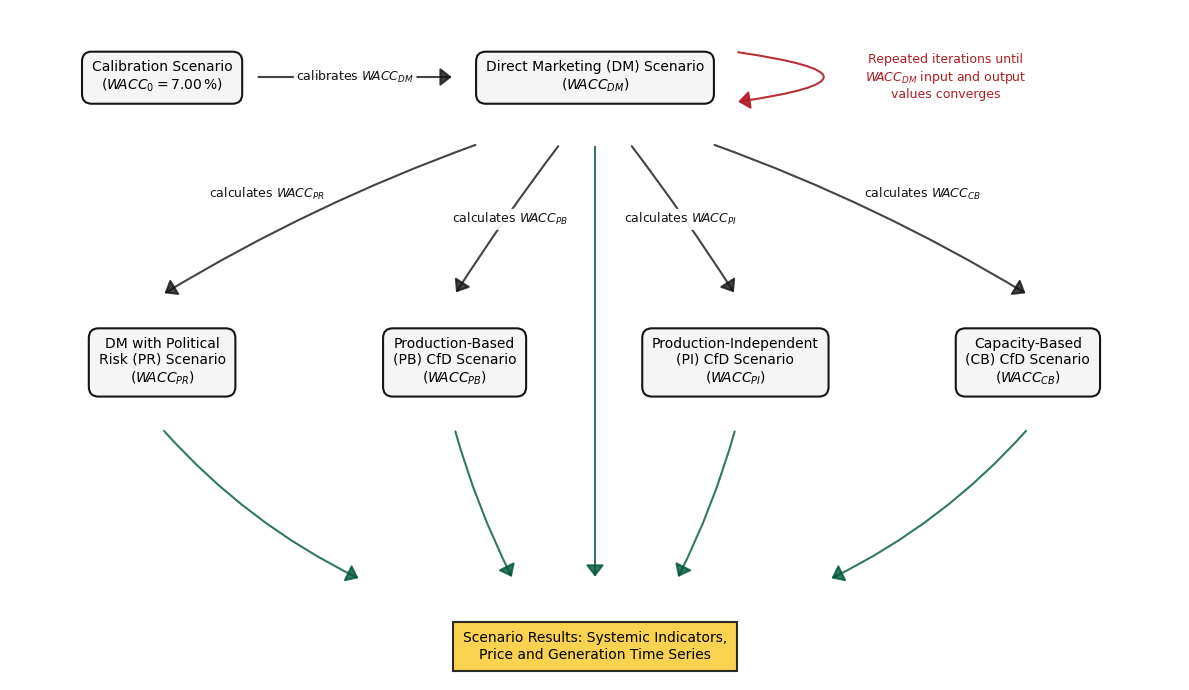

In [40]:
importlib.reload(af)
af.plot_wacc_scenario_workflow()